In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
# Importing dataset
df = pd.read_csv(r"C:\Users\karth\apexplanet-data-analytics\data\Sample - Superstore_with_missing_and_duplicates.csv",encoding="cp1252")

df.head()

#df.shape
#df.columns

#df.tail()




,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


In [4]:
# Check missing values
print(df.isnull().sum())

# Categorical columns
categorical_cols = ["Ship Mode", "Customer Name", "City", "Region", "Category"]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Numerical columns
df["Postal Code"] = df["Postal Code"].fillna(df["Postal Code"].median())
df["Sales"] = df["Sales"].fillna(df["Sales"].mean())
df["Quantity"] = df["Quantity"].fillna(df["Quantity"].median())
df["Discount"] = df["Discount"].fillna(df["Discount"].mean())
df["Profit"] = df["Profit"].fillna(df["Profit"].mean())


print("\nMissing values after filling:")
print(df.isnull().sum())

# Checking duplicates
print(df.duplicated().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

# Verify
print(df.duplicated().sum())


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        1
Customer ID      0
Customer Name    1
Segment          0
Country          0
City             1
State            0
Postal Code      1
Region           1
Product ID       0
Category         1
Sub-Category     0
Product Name     0
Sales            7
Quantity         1
Discount         1
Profit           7
dtype: int64

Missing values after filling:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
5
0


In [5]:
# Convert date columns
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Convert categorical columns
categorical_cols = [
    "Ship Mode",
    "Segment",
    "Country",
    "City",
    "State",
    "Region",
    "Category",
    "Sub-Category"
]

for col in categorical_cols:
    df[col] = df[col].astype("category")

# Verify
print(df.dtypes)

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode              category
Customer ID              object
Customer Name            object
Segment                category
Country                category
City                   category
State                  category
Postal Code             float64
Region                 category
Product ID               object
Category               category
Sub-Category           category
Product Name             object
Sales                   float64
Quantity                float64
Discount                float64
Profit                  float64
dtype: object


In [6]:
# Handle IQR method for multiple columns(Remove Outliers)
numeric_cols = ["Sales", "Profit", "Quantity", "Discount"]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print(df.shape)

# Save cleaned dataset
df.to_csv(
    r"C:\Users\karth\apexplanet-data-analytics\data\Superstore_Cleaned.csv",
    index=False,
    encoding="cp1252"
)

print("Dataset saved successfully!")

(6715, 21)
Dataset saved successfully!


In [7]:
# Statistical summary
df.describe(include='category')

,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category
count,6715,6715,6715,6715,6715,6715,6715,6715
unique,4,3,1,496,48,4,3,16
top,Standard Class,Consumer,United States,New York City,California,West,Office Supplies,Paper
freq,3996,3511,6715,667,1525,2359,4489,1175


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6715 entries, 0 to 9992
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         6715 non-null   int64         
 1   Order ID       6715 non-null   object        
 2   Order Date     6715 non-null   datetime64[ns]
 3   Ship Date      6715 non-null   datetime64[ns]
 4   Ship Mode      6715 non-null   category      
 5   Customer ID    6715 non-null   object        
 6   Customer Name  6715 non-null   object        
 7   Segment        6715 non-null   category      
 8   Country        6715 non-null   category      
 9   City           6715 non-null   category      
 10  State          6715 non-null   category      
 11  Postal Code    6715 non-null   float64       
 12  Region         6715 non-null   category      
 13  Product ID     6715 non-null   object        
 14  Category       6715 non-null   category      
 15  Sub-Category   6715 non-nu

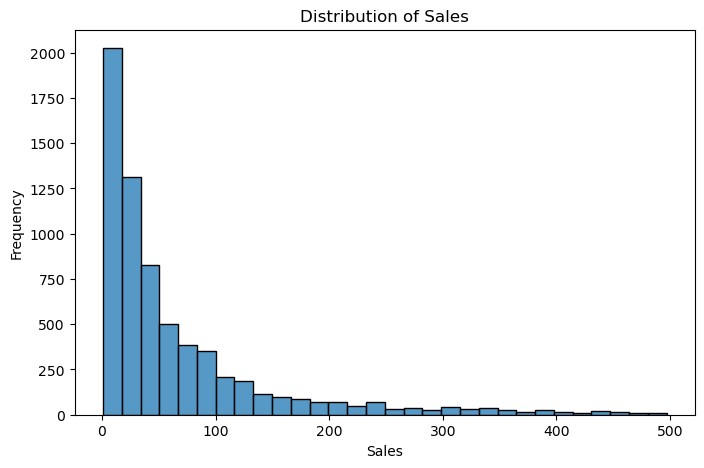

In [7]:
# Create Visulaizations

# 1.Histogram 
plt.figure(figsize=(8,5))
sns.histplot(df["Sales"], bins=30)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

### Observation

- The Sales distribution is right-skewed.
- Most orders have relatively low sales values.
- A few orders have very high sales values, creating a long right tail.
- This indicates that high-value transactions are less frequent.

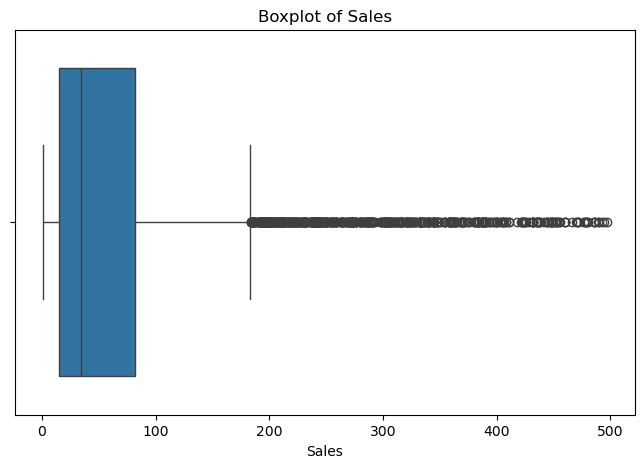

In [8]:
# 2.Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Sales"])
plt.title("Boxplot of Sales")
plt.show()

### Observation

- The Sales column contains several outliers.
- Most sales values lie within the interquartile range (IQR).
- The outliers represent unusually large sales transactions.

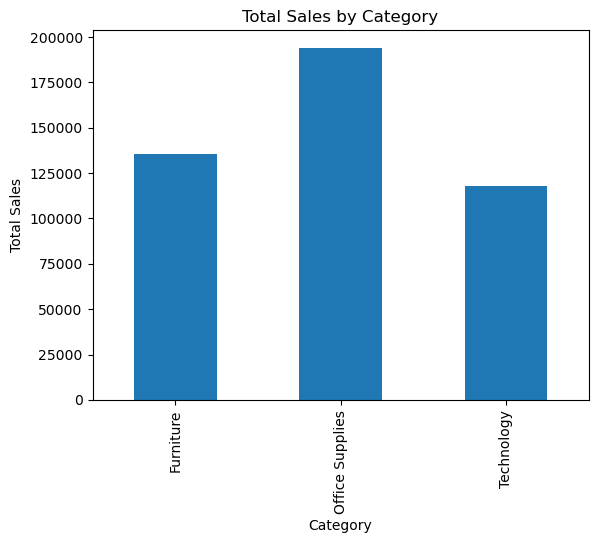

In [9]:
# 3.Barchart
category_sales = df.groupby("Category", observed=False)["Sales"].sum()
category_sales.plot(kind="bar")
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

### Observation

- The Technology category generated the highest total sales.
- Furniture ranked second.
- Office Supplies contributed a large number of orders but comparatively lower total sales.

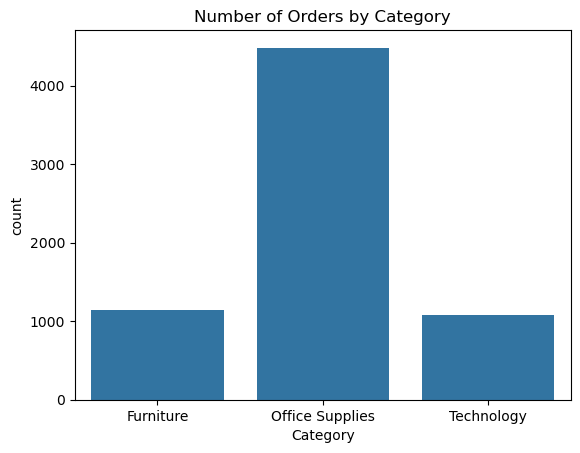

In [10]:
# 4.Count plot
sns.countplot(x="Category", data=df)
plt.title("Number of Orders by Category")
plt.show()

### Observation

- Office Supplies has the highest number of orders.
- Furniture has fewer orders.
- Technology has the lowest order count among the three categories.

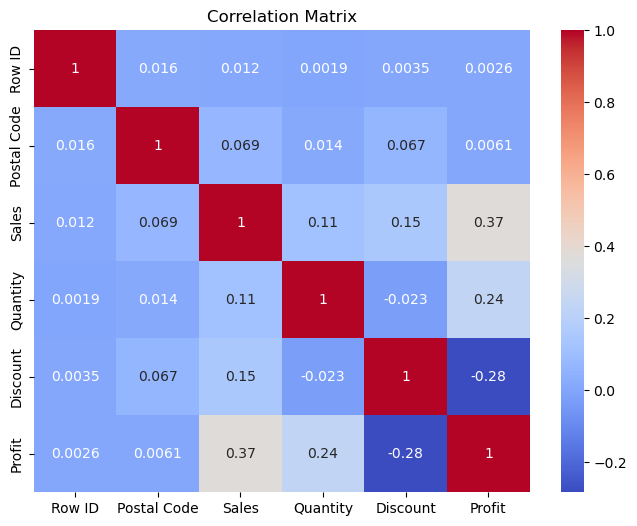

In [11]:
# 3.Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

### Observation

- Sales and Profit show a positive correlation.
- Discount has a negative correlation with Profit.
- Quantity has only a weak relationship with Sales.

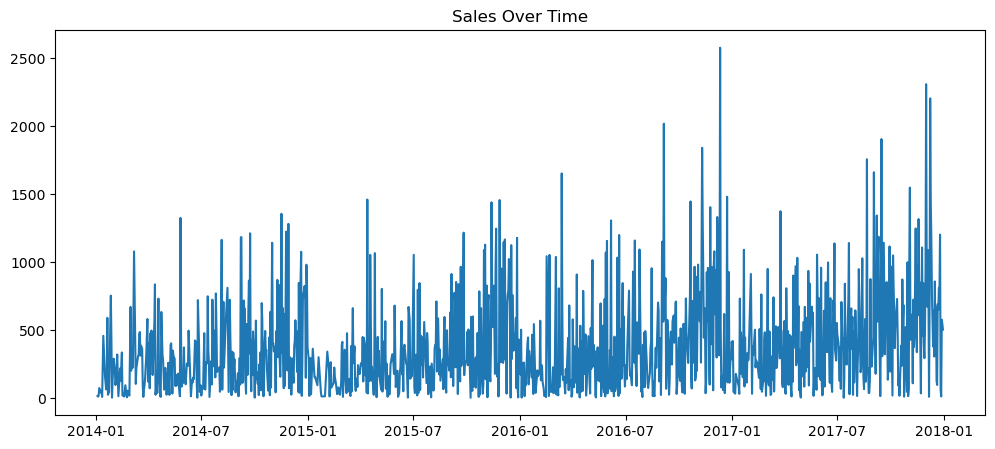

In [12]:
# 6.Line chart
sales_date = df.groupby("Order Date")["Sales"].sum()

plt.figure(figsize=(12,5))
plt.plot(sales_date)

plt.title("Sales Over Time")
plt.show()

### Observation

- Sales fluctuate over time.
- Certain periods show noticeable peaks in sales.
- There is no consistent upward or downward trend across the entire period.

# Key Insights

### Insight 1
The Technology category generated the highest total sales, indicating strong customer demand for technology products.

### Insight 2
Office Supplies had the highest number of orders, showing that customers purchase these items more frequently.

### Insight 3
The Sales distribution is right-skewed, with most orders having low sales and a few orders contributing very high sales.

### Insight 4
The Sales column contains several outliers, representing unusually large transactions.

### Insight 5
Sales and Profit are positively correlated, meaning that higher sales generally result in higher profits.

## Conclusion

The dataset was cleaned by handling missing values, removing duplicate records, correcting data types, and treating outliers. Exploratory Data Analysis revealed patterns in sales, product categories, and profit. The visualizations helped identify distribution, relationships, and trends that can support better business decision-making.